1. Read the data

In [1]:
import pandas as pd

# Read the dataset
df = pd.read_csv(
    r"C:\Users\shade\OneDrive\Documents\Samsung Bootcamp\Project\Customer-Support-Tickets\Prompted\data\final_ml_ready_support_tickets.csv"
)
# Check the dataset shape
print(df.shape)

# Display column names
print(df.columns.tolist())

(17217, 19)
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'norm_subj', 'norm_body', 'ticket_key']


In [2]:
df["priority"].value_counts()

priority
medium    7134
high      6582
low       3501
Name: count, dtype: int64

In [3]:
# Create the text feature
df["text"] = (
    df["subject"].fillna("") + " " +
    df["body"].fillna("")
)

# Define features and target
X = df["text"]
y = df["priority"]

# Check the target distribution
print(y.value_counts())

priority
medium    7134
high      6582
low       3501
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 13773
Testing samples: 3444


TF-IDF

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2)
)

# Fit on training data only
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the same vocabulary
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (13773, 20000)
Testing TF-IDF shape: (3444, 20000)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Create the baseline Logistic Regression model
priority_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
priority_lr.fit(X_train_tfidf, y_train)

# Make predictions
priority_lr_pred = priority_lr.predict(X_test_tfidf)

# Evaluate the model
priority_lr_accuracy = accuracy_score(y_test, priority_lr_pred)
priority_lr_macro_f1 = f1_score(
    y_test,
    priority_lr_pred,
    average="macro"
)

print("Priority Logistic Regression Accuracy:", priority_lr_accuracy)
print("Priority Logistic Regression Macro-F1:", priority_lr_macro_f1)

print("\nClassification Report:")
print(classification_report(y_test, priority_lr_pred))

Priority Logistic Regression Accuracy: 0.5612659698025552
Priority Logistic Regression Macro-F1: 0.4982894448041047

Classification Report:
              precision    recall  f1-score   support

        high       0.59      0.61      0.60      1317
         low       0.58      0.19      0.29       700
      medium       0.54      0.70      0.61      1427

    accuracy                           0.56      3444
   macro avg       0.57      0.50      0.50      3444
weighted avg       0.57      0.56      0.54      3444



Linear SVM

In [7]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Create the baseline Linear SVM model
priority_svm = LinearSVC(
    random_state=42
)

# Train the model
priority_svm.fit(X_train_tfidf, y_train)

# Make predictions
priority_svm_pred = priority_svm.predict(X_test_tfidf)

# Evaluate the model
priority_svm_accuracy = accuracy_score(
    y_test,
    priority_svm_pred
)

priority_svm_macro_f1 = f1_score(
    y_test,
    priority_svm_pred,
    average="macro"
)

print("Priority Linear SVM Accuracy:", priority_svm_accuracy)
print("Priority Linear SVM Macro-F1:", priority_svm_macro_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        priority_svm_pred
    )
)

Priority Linear SVM Accuracy: 0.6144018583042973
Priority Linear SVM Macro-F1: 0.5903105087772363

Classification Report:
              precision    recall  f1-score   support

        high       0.63      0.66      0.64      1317
         low       0.59      0.42      0.49       700
      medium       0.61      0.67      0.64      1427

    accuracy                           0.61      3444
   macro avg       0.61      0.58      0.59      3444
weighted avg       0.61      0.61      0.61      3444



Naive Bayes

In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Create the Naive Bayes model
priority_nb = MultinomialNB()

# Train the model
priority_nb.fit(X_train_tfidf, y_train)

# Make predictions
priority_nb_pred = priority_nb.predict(X_test_tfidf)

# Evaluate the model
priority_nb_accuracy = accuracy_score(
    y_test,
    priority_nb_pred
)

priority_nb_macro_f1 = f1_score(
    y_test,
    priority_nb_pred,
    average="macro"
)

print("Priority Naive Bayes Accuracy:", priority_nb_accuracy)
print("Priority Naive Bayes Macro-F1:", priority_nb_macro_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        priority_nb_pred
    )
)

Priority Naive Bayes Accuracy: 0.498548199767712
Priority Naive Bayes Macro-F1: 0.3811412206968392

Classification Report:
              precision    recall  f1-score   support

        high       0.52      0.55      0.53      1317
         low       0.94      0.02      0.04       700
      medium       0.48      0.69      0.56      1427

    accuracy                           0.50      3444
   macro avg       0.65      0.42      0.38      3444
weighted avg       0.59      0.50      0.45      3444



SGD

In [9]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Create the SGD classifier
priority_sgd = SGDClassifier(
    loss="hinge",
    random_state=42
)

# Train the model
priority_sgd.fit(X_train_tfidf, y_train)

# Make predictions
priority_sgd_pred = priority_sgd.predict(X_test_tfidf)

# Evaluate the model
priority_sgd_accuracy = accuracy_score(
    y_test,
    priority_sgd_pred
)

priority_sgd_macro_f1 = f1_score(
    y_test,
    priority_sgd_pred,
    average="macro"
)

print("Priority SGD Accuracy:", priority_sgd_accuracy)
print("Priority SGD Macro-F1:", priority_sgd_macro_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        priority_sgd_pred
    )
)

Priority SGD Accuracy: 0.5717189314750291
Priority SGD Macro-F1: 0.5162313322419984

Classification Report:
              precision    recall  f1-score   support

        high       0.60      0.61      0.60      1317
         low       0.63      0.22      0.33       700
      medium       0.55      0.71      0.62      1427

    accuracy                           0.57      3444
   macro avg       0.59      0.51      0.52      3444
weighted avg       0.58      0.57      0.55      3444



Balanced Logistic Regression

In [10]:
# Balanced Logistic Regression
priority_lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

priority_lr_balanced.fit(X_train_tfidf, y_train)

priority_lr_balanced_pred = priority_lr_balanced.predict(X_test_tfidf)

priority_lr_balanced_accuracy = accuracy_score(
    y_test,
    priority_lr_balanced_pred
)

priority_lr_balanced_macro_f1 = f1_score(
    y_test,
    priority_lr_balanced_pred,
    average="macro"
)

print(
    "Balanced Logistic Regression Accuracy:",
    priority_lr_balanced_accuracy
)

print(
    "Balanced Logistic Regression Macro-F1:",
    priority_lr_balanced_macro_f1
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        priority_lr_balanced_pred
    )
)

Balanced Logistic Regression Accuracy: 0.5577816492450639
Balanced Logistic Regression Macro-F1: 0.5467128933733402

Classification Report:
              precision    recall  f1-score   support

        high       0.62      0.59      0.60      1317
         low       0.42      0.54      0.47       700
      medium       0.60      0.54      0.57      1427

    accuracy                           0.56      3444
   macro avg       0.54      0.55      0.55      3444
weighted avg       0.57      0.56      0.56      3444



In [11]:
# Balanced Linear SVM
priority_svm_balanced = LinearSVC(
    class_weight="balanced",
    random_state=42
)

# Train the model
priority_svm_balanced.fit(X_train_tfidf, y_train)

# Make predictions
priority_svm_balanced_pred = priority_svm_balanced.predict(
    X_test_tfidf
)

# Evaluate the model
priority_svm_balanced_accuracy = accuracy_score(
    y_test,
    priority_svm_balanced_pred
)

priority_svm_balanced_macro_f1 = f1_score(
    y_test,
    priority_svm_balanced_pred,
    average="macro"
)

print(
    "Balanced Linear SVM Accuracy:",
    priority_svm_balanced_accuracy
)

print(
    "Balanced Linear SVM Macro-F1:",
    priority_svm_balanced_macro_f1
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        priority_svm_balanced_pred
    )
)

Balanced Linear SVM Accuracy: 0.6091753774680604
Balanced Linear SVM Macro-F1: 0.5934786580514598

Classification Report:
              precision    recall  f1-score   support

        high       0.64      0.64      0.64      1317
         low       0.51      0.51      0.51       700
      medium       0.63      0.63      0.63      1427

    accuracy                           0.61      3444
   macro avg       0.59      0.59      0.59      3444
weighted avg       0.61      0.61      0.61      3444



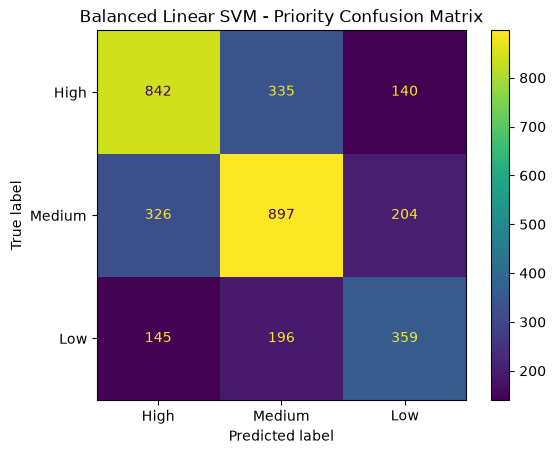

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    priority_svm_balanced_pred,
    labels=["high", "medium", "low"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["High", "Medium", "Low"]
)

disp.plot()
plt.title("Balanced Linear SVM - Priority Confusion Matrix")
plt.show()

In [13]:
cost_matrix = {
    "high":   {"high": 0, "medium": 5, "low": 10},
    "medium": {"high": 3, "medium": 0, "low": 5},
    "low":    {"high": 5, "medium": 2, "low": 0}
}

In [14]:
cost_matrix = {
    "high":   {"high": 0, "medium": 5, "low": 10},
    "medium": {"high": 3, "medium": 0, "low": 5},
    "low":    {"high": 5, "medium": 2, "low": 0}
}

total_cost = 0

for actual, predicted in zip(y_test, priority_svm_balanced_pred):
    total_cost += cost_matrix[actual][predicted]

average_cost = total_cost / len(y_test)

print("Total Business Cost:", total_cost)
print("Average Business Cost:", average_cost)

Total Business Cost: 6190
Average Business Cost: 1.79732868757259


In [15]:
priority_svm_pred

array(['medium', 'high', 'high', ..., 'low', 'medium', 'high'],
      shape=(3444,), dtype=object)

In [16]:
total_cost_svm = 0

for actual, predicted in zip(y_test, priority_svm_pred):
    total_cost_svm += cost_matrix[actual][predicted]

average_cost_svm = total_cost_svm / len(y_test)

print("Linear SVM Total Business Cost:", total_cost_svm)
print("Linear SVM Average Business Cost:", average_cost_svm)

Linear SVM Total Business Cost: 5641
Linear SVM Average Business Cost: 1.6379210220673635


In [17]:
# Create error analysis dataframe

error_analysis = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": priority_svm_pred
})

# Keep only incorrect predictions
errors = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
].copy()

print("Total errors:", len(errors))
print("\nError types:")
print(
    errors.groupby(["actual", "predicted"])
    .size()
    .sort_values(ascending=False)
)

Total errors: 1328

Error types:
actual  predicted
high    medium       367
medium  high         350
low     medium       243
        high         164
medium  low          118
high    low           86
dtype: int64


In [18]:
print("=== High → Low ===")

high_low_errors = errors[
    (errors["actual"] == "high") &
    (errors["predicted"] == "low")
]

display(
    high_low_errors[["text", "actual", "predicted"]].head(10)
)


print("\n=== High → Medium ===")

high_medium_errors = errors[
    (errors["actual"] == "high") &
    (errors["predicted"] == "medium")
]

display(
    high_medium_errors[["text", "actual", "predicted"]].head(10)
)

=== High → Low ===


,text,actual,predicted
9,"Growth Strategies in Digital Customer Support,...",high,low
12,Problem with Investment Analysis Software The ...,high,low
156,Marketing Assistance Needed The digital strate...,high,low
160,Report on Unusual Billing Issue An unexpected ...,high,low
188,Enhancing Medical Data Security It is crucial ...,high,low
212,Strategies for Expanding Digital Brand Presenc...,high,low
291,Guidance on Securing Medical Data in BenQ TK85...,high,low
326,Encountered Data Synchronization Issues Today ...,high,low
393,MacBook Air Dashboard Stalls The data analytic...,high,low
414,Problems with Synchronizing Financial Data Dea...,high,low



=== High → Medium ===


,text,actual,predicted
0,Billing Invoice Discrepancy with Incorrect Cha...,high,medium
22,Strategies for Enhancing Brand with Technology...,high,medium
40,Recurring Charges Inquiry Unexpected duplicate...,high,medium
54,Project Delay Project loading times have been ...,high,medium
80,Issue with Discrepancy in Digital Campaign Met...,high,medium
83,Software Problem Facing difficulties with vari...,high,medium
95,Support for Smartsheet Users are unable to syn...,high,medium
117,"Campaign Launch Issue Hello Customer Support, ...",high,medium
131,Enhancing Investment Approaches with Data Anal...,high,medium
137,Boosting Brand Expansion through Effective Onl...,high,medium


In [19]:
pd.set_option("display.max_colwidth", 500)

display(
    high_low_errors[
        ["text", "actual", "predicted"]
    ].head(10)
)

,text,actual,predicted
9,"Growth Strategies in Digital Customer Support, seeking detailed information on digital strategies and services related to brand growth. Specifically, could you provide details on the services you offer, such as social media management, content creation, and SEO optimization? Also, would be grateful for information on the associated products, marketing software, and analytics tools. Additionally, could you share some case studies or examples of successful campaigns you have managed in the pas...",high,low
12,"Problem with Investment Analysis Software The investment analysis application has encountered an unexpected failure. Steps already taken include a system reboot, reviewing for recent updates, and ensuring the accuracy of the input data. Despite these actions, the problem remains unresolved and may be related to either an overload of data or a compatibility issue.",high,low
156,"Marketing Assistance Needed The digital strategy implemented by our marketing agency is not yielding the desired results, leading to sluggish brand expansion. We have experimented with adjusting campaigns through A/B testing and observed some progress. However, ineffective targeting may be contributing to the problem. We seek assistance in diagnosing the issue and finding solutions to reignite our brand growth. Could you offer guidance on enhancing our digital strategy targeting?",high,low
160,"Report on Unusual Billing Issue An unexpected billing error has been found in our account statement. This could be due to a flaw in the billing system or a mistake in processing payments. We have double-checked our payment records and have previously reached out to customer support, yet the problem continues. We would be grateful for your swift assistance in addressing this situation.",high,low
188,"Enhancing Medical Data Security It is crucial to implement updated security protocols to enhance the protection of medical data within our hospital system. This includes regular software updates, secure authentication methods, and access controls to prevent any unauthorized access.",high,low
212,Strategies for Expanding Digital Brand Presence Can you share insights into the digital tactics employed by your agency to effectively enhance brand development?,high,low
291,Guidance on Securing Medical Data in BenQ TK850 Hospital Settings I require assistance in securing medical data within the BenQ TK850 hospital environment. Could you offer some recommended practices to ensure the security and integrity of sensitive medical information?,high,low
326,"Encountered Data Synchronization Issues Today We faced data synchronization problems across our investment analytics platforms, impacting real-time reporting, likely because of recent software updates. Restarting the devices and resyncing the services resolved the issue.",high,low
393,"MacBook Air Dashboard Stalls The data analytics dashboard frequently halts on my MacBook Air. It seems there might be a conflict with recent software updates, potentially affecting the Express.js functionality. I've restarted the device, verified Subversion, and updated WordPress, yet the problem still occurs.",high,low
414,"Problems with Synchronizing Financial Data Dear Customer Support, I am reaching out regarding inconsistent data synchronization that is causing delays in receiving investment insights from our financial analytics tools. Despite performing initial troubleshooting steps such as software updates, the problem remains unresolved. It seems there may be underlying integration issues contributing to the problem. Our team has attempted to address this internally without success. We are concerned that...",high,low


Error Analysis:
The main priority classification errors occurred between adjacent priority levels, particularly High → Medium and Medium → High. A smaller but more critical set of errors involved High → Low. Analysis of High → Low examples showed that priority is not always explicitly expressed through urgency-related keywords. Some tickets describe technical, security, billing, or synchronization issues without clearly stating their business impact or urgency. Since the TF-IDF + Linear SVM approach relies primarily on textual patterns, it may confuse the topic or nature of an issue with its actual priority. This highlights the limitation of text-only priority classification and suggests that future improvements could incorporate contextual features such as business impact, affected users, service availability, urgency, and resolution status.

We identified class imbalance as a potential issue and evaluated class-weighted Linear SVM using class_weight="balanced". Although balancing improved the minority-class recall and slightly improved Macro-F1, it increased the overall business cost and slightly reduced accuracy. Therefore, we selected the baseline Linear SVM based on the overall evaluation criteria.

In [20]:
# ============================================================
# Print Comparison
# ============================================================

print("=" * 60)
print("PRIORITY MODEL COMPARISON")
print("=" * 60)

print("\nBaseline Linear SVM")
print("-" * 30)
print(f"Accuracy : {priority_svm_accuracy:.4f}")
print(f"Macro-F1 : {priority_svm_macro_f1:.4f}")

print("\nBalanced Linear SVM")
print("-" * 30)
print(f"Accuracy : {priority_svm_balanced_accuracy:.4f}")
print(f"Macro-F1 : {priority_svm_balanced_macro_f1:.4f}")

print("\n" + "=" * 60)
print("FINAL PRIORITY MODEL: Linear SVM")
print("=" * 60)

print(f"Final Accuracy : {priority_svm_accuracy:.4f}")
print(f"Final Macro-F1 : {priority_svm_macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        priority_svm_pred
    )
)

PRIORITY MODEL COMPARISON

Baseline Linear SVM
------------------------------
Accuracy : 0.6144
Macro-F1 : 0.5903

Balanced Linear SVM
------------------------------
Accuracy : 0.6092
Macro-F1 : 0.5935

FINAL PRIORITY MODEL: Linear SVM
Final Accuracy : 0.6144
Final Macro-F1 : 0.5903

Classification Report:
              precision    recall  f1-score   support

        high       0.63      0.66      0.64      1317
         low       0.59      0.42      0.49       700
      medium       0.61      0.67      0.64      1427

    accuracy                           0.61      3444
   macro avg       0.61      0.58      0.59      3444
weighted avg       0.61      0.61      0.61      3444



In [22]:
import joblib

# Save the final Priority TF-IDF vectorizer
joblib.dump(
    tfidf,
    "Models\priority_tfidf.pkl"
)

# Save the final Priority Linear SVM model
joblib.dump(
    priority_svm,
    "Models\priority_svm.pkl"
)

print("=" * 60)
print("FILES SAVED SUCCESSFULLY")
print("=" * 60)
print("priority_tfidf.pkl")
print("priority_svm.pkl")

<>:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:12: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:12: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\shade\AppData\Local\Temp\ipykernel_4972\4216063664.py:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  "Models\priority_tfidf.pkl"
C:\Users\shade\AppData\Local\Temp\ipykernel_4972\4216063664.py:12: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not w

FILES SAVED SUCCESSFULLY
priority_tfidf.pkl
priority_svm.pkl
